In [ ]:


import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


In [3]:
df=pd.read_csv("car data.csv")

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.shape

(301, 9)

In [6]:
print(df['Fuel_Type'].unique())
print(df['Seller_Type'].unique())
print(df['Transmission'].unique())
print(df['Owner'].unique())

['Petrol' 'Diesel' 'CNG']
['Dealer' 'Individual']
['Manual' 'Automatic']
[0 1 3]


In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.00,301.00,301.00,301.00,301.00
mean,2013.63,4.66,7.63,36947.21,0.04
std,2.89,5.08,8.64,38886.88,0.25
min,2003.00,0.10,0.32,500.00,0.00
25%,2012.00,0.90,1.20,15000.00,0.00
50%,2014.00,3.60,6.40,32000.00,0.00
75%,2016.00,6.00,9.90,48767.00,0.00
max,2018.00,35.00,92.60,500000.00,3.00


In [9]:
df= df.drop('Car_Name', axis=1)

In [10]:
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [11]:
df['This_Year']= 2024
df['Number_Of_Years']=df['This_Year']-df['Year']
df= df.drop('Year', axis=1)
df= df.drop('This_Year', axis=1)

In [12]:

df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Number_Of_Years
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


In [13]:
from sklearn.preprocessing import LabelEncoder



# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the categorical column
df['Fuel_Type_encoded'] = label_encoder.fit_transform(df['Fuel_Type'])
df['Seller_Type_encoded'] = label_encoder.fit_transform(df['Seller_Type'])
df['Transmission_encoded'] = label_encoder.fit_transform(df['Transmission'])
df['Owner_encoded'] = label_encoder.fit_transform(df['Owner'])
df= df.drop('Fuel_Type', axis=1)
df= df.drop('Seller_Type', axis=1)
df= df.drop('Transmission', axis=1)
df= df.drop('Owner', axis=1)

In [14]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Number_Of_Years,Fuel_Type_encoded,Seller_Type_encoded,Transmission_encoded,Owner_encoded
0,3.35,5.59,27000,10,2,0,1,0
1,4.75,9.54,43000,11,1,0,1,0
2,7.25,9.85,6900,7,2,0,1,0
3,2.85,4.15,5200,13,2,0,1,0
4,4.60,6.87,42450,10,1,0,1,0


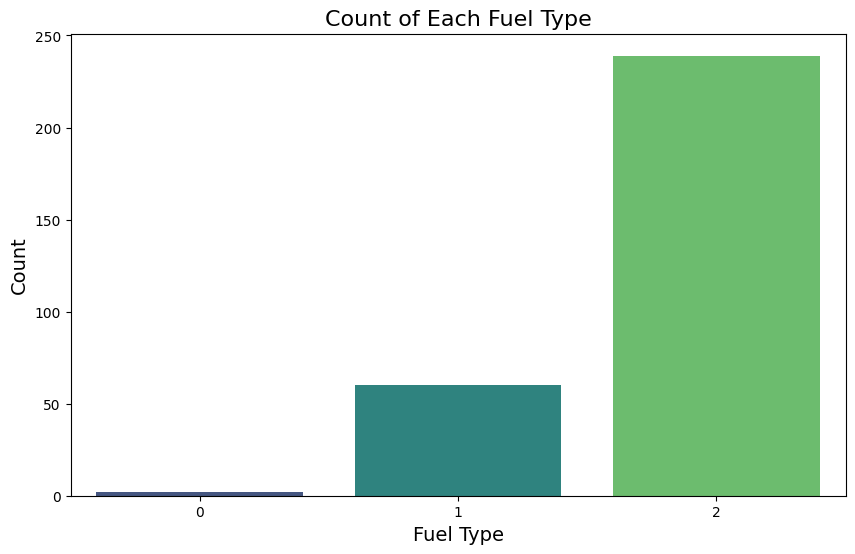

In [15]:
## 3. Exploratory Data Analysis¶
import seaborn as sns
import matplotlib.pyplot as plt

# Create the count plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Fuel_Type_encoded', palette='viridis')

# Add title and labels
plt.title('Count of Each Fuel Type', fontsize=16)
plt.xlabel('Fuel Type', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Show plot
plt.show()

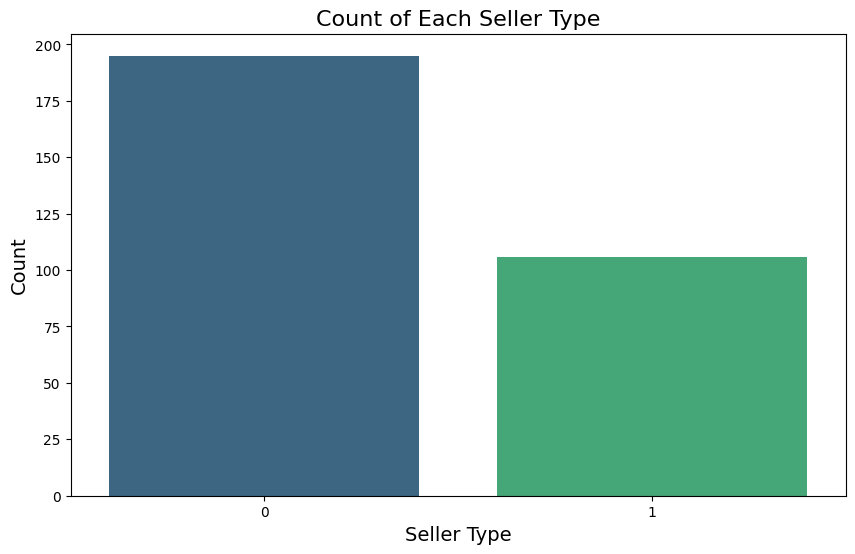

In [16]:
# Create the count plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Seller_Type_encoded', palette='viridis')

# Add title and labels
plt.title('Count of Each Seller Type', fontsize=16)
plt.xlabel('Seller Type', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Show plot
plt.show()

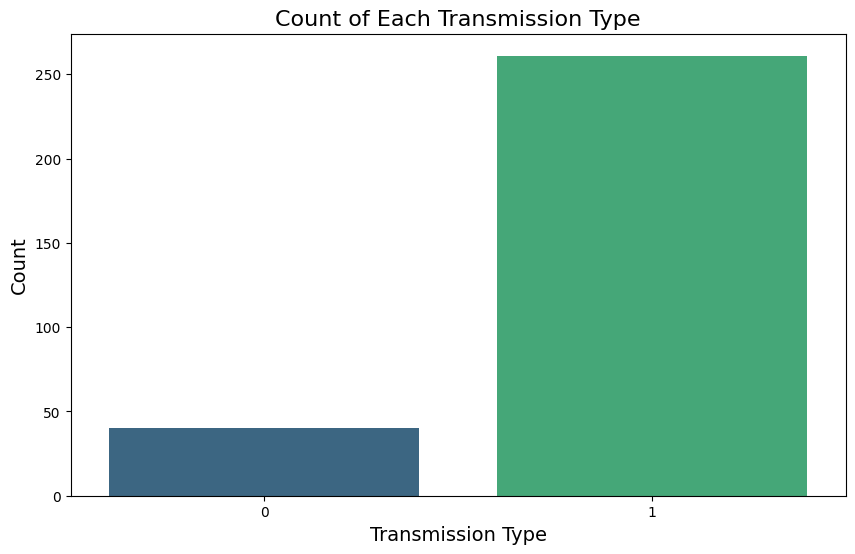

In [17]:
# Create the count plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Transmission_encoded', palette='viridis')

# Add title and labels
plt.title('Count of Each Transmission Type', fontsize=16)
plt.xlabel('Transmission Type', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Show plot
plt.show()

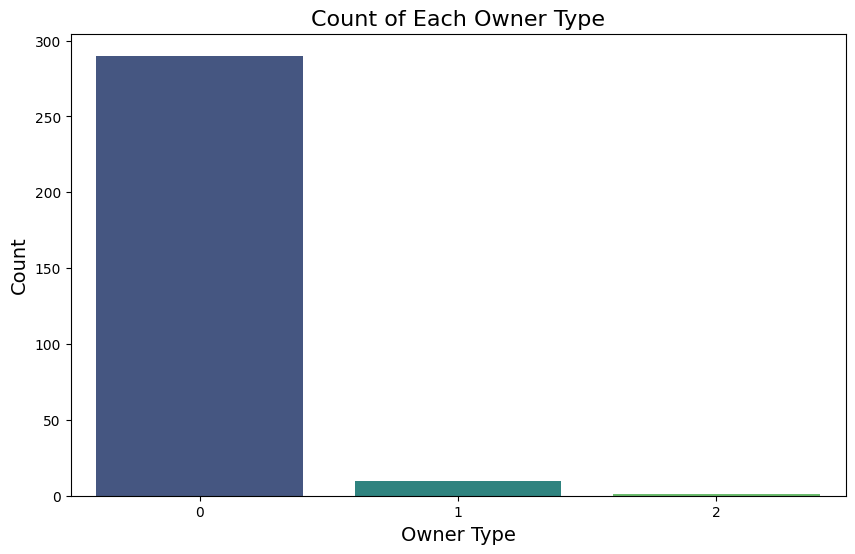

In [18]:
# Create the count plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Owner_encoded', palette='viridis')

# Add title and labels
plt.title('Count of Each Owner Type', fontsize=16)
plt.xlabel('Owner Type', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Show plot
plt.show()

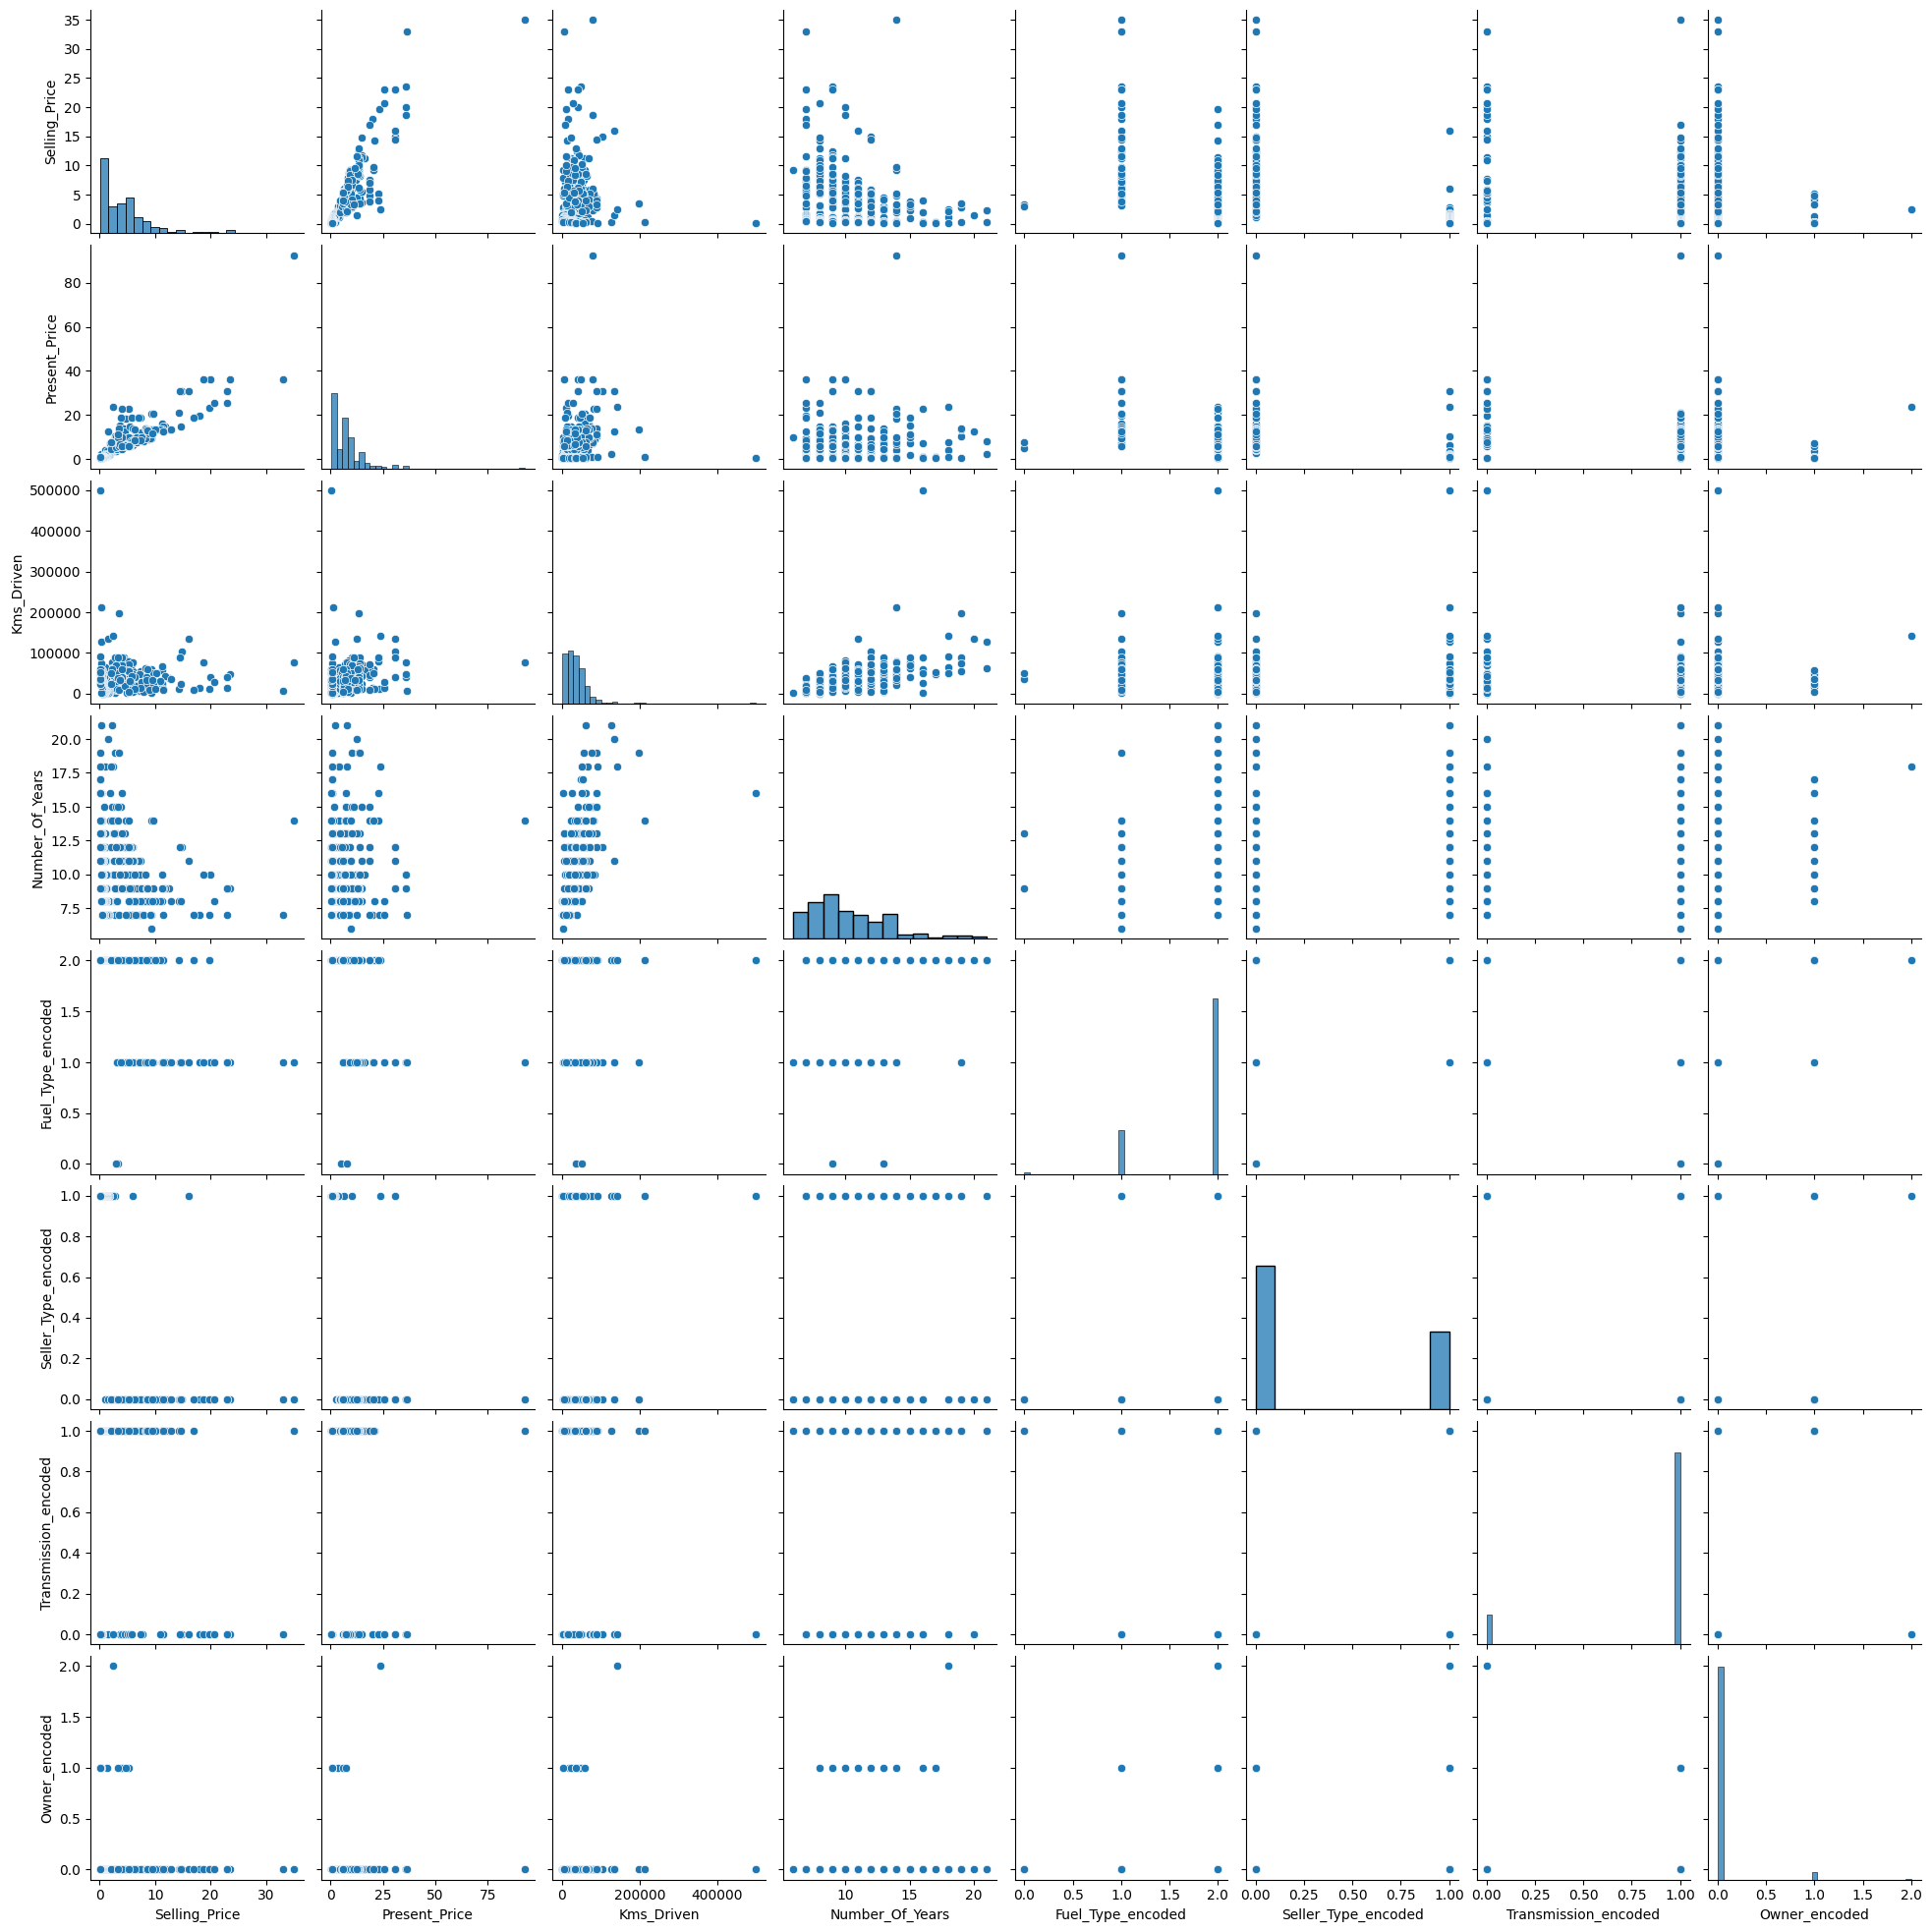

In [19]:
import seaborn as sns 
import warnings

sns.pairplot(df)

# Ignore all FutureWarning messages
warnings.simplefilter(action='ignore', category=FutureWarning)

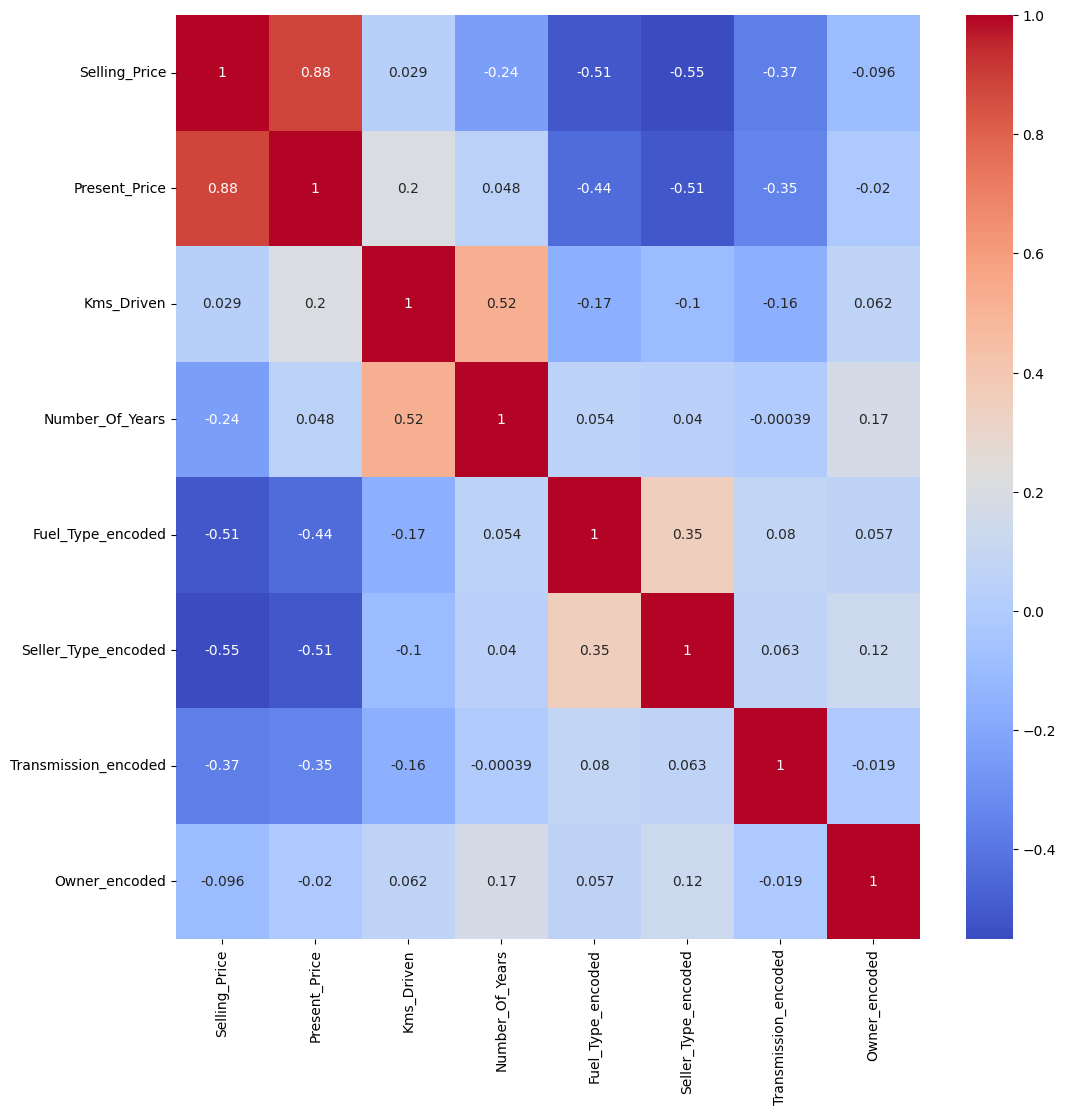

In [20]:
corr= df.corr()
plt.figure(figsize=(12,12))
g=sns.heatmap(corr, annot=True, cmap='coolwarm')

In [21]:
df= df.drop('Owner_encoded', axis=1)
df= df.drop('Kms_Driven', axis=1)

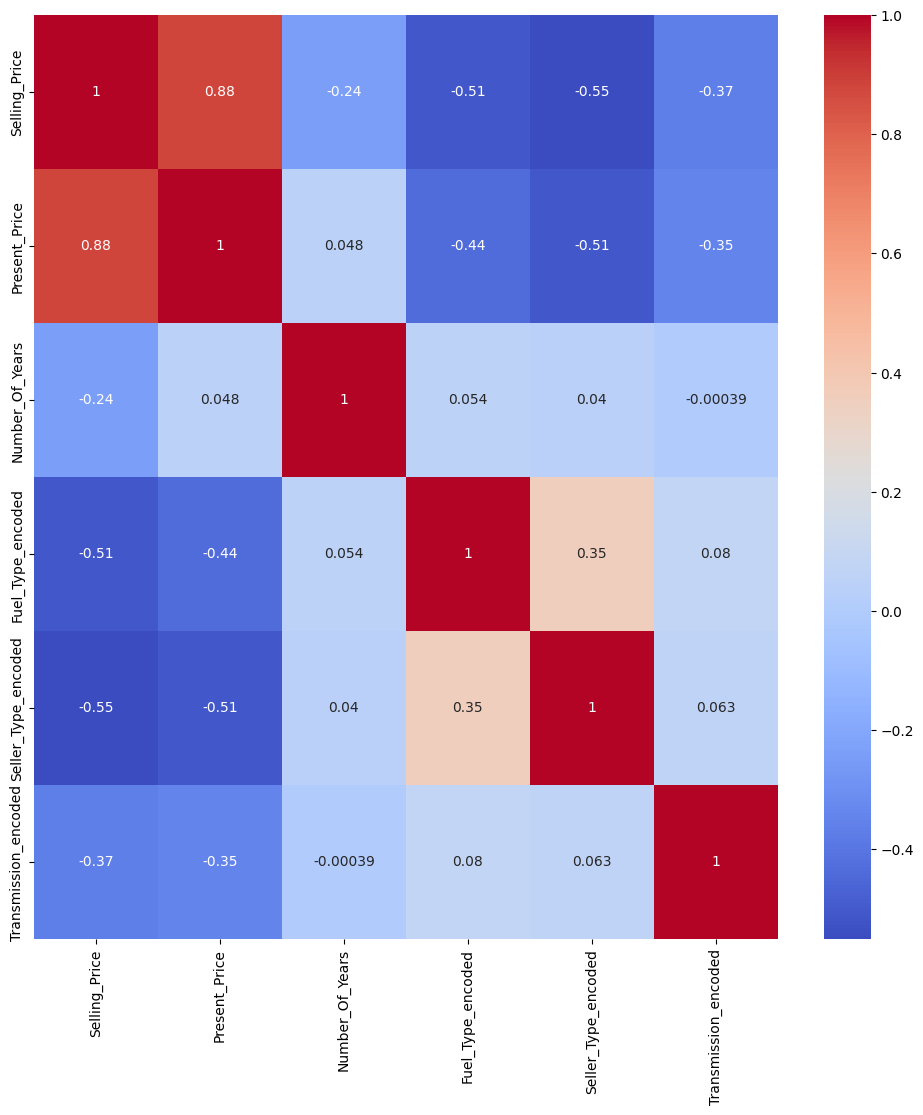

In [22]:
corr= df.corr()
plt.figure(figsize=(12,12))
g=sns.heatmap(corr, annot=True, cmap='coolwarm')

In [23]:
## 5. Rapid Model Benchmarking: LazyPredict
import pandas as pd
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyRegressor


# df is  DataFrame and Selling_Price is the target
X = df.drop('Selling_Price', axis=1)  # Features
y = df['Selling_Price']               # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit LazyRegressor
regressor = LazyRegressor()
models = regressor.fit(X_train, X_test, y_train, y_test)

# Display the results
print(models)

  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000138 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 86
[LightGBM] [Info] Number of data points in the train set: 240, number of used features: 5
[LightGBM] [Info] Start training from score 4.642292
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [24]:
#GradientBoostingRegressor 
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


# Initialize the GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)

# Fit the model on the training data
gbr.fit(X_train, y_train)

# Make predictions on the test data
y_pred = gbr.predict(X_test)

# Calculate R-squared
r_squared = r2_score(y_test, y_pred)

# Calculate Adjusted R-squared
n = X_test.shape[0]  # Number of samples
p = X_test.shape[1]  # Number of features
adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print the results
print(f"R-squared: {r_squared}")
print(f"Adjusted R-squared: {adjusted_r_squared}")
print(f"RMSE: {rmse}")

# Optionally, print the first few predicted values alongside the actual values
print(pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).head())

R-squared: 0.9726452935303832
Adjusted R-squared: 0.9701585020331454
RMSE: 0.7938083225241399
     Actual  Predicted
177    0.35       0.61
289   10.11      10.23
228    4.95       4.69
198    0.15       0.28
60     6.95       6.89


In [25]:
# Gradient Boosting: Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

from scipy.stats import uniform, randint



# Initialize the GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)

# Define the parameter grid for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(50, 500),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'subsample': uniform(0.7, 0.3)
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(gbr, param_distributions=param_dist, 
                                   n_iter=500, scoring='neg_mean_squared_error', 
                                   cv=5, random_state=42, n_jobs=-1)

# Fit the model with RandomizedSearchCV
random_search.fit(X_train, y_train)

# Get the best model from RandomizedSearchCV
best_model = random_search.best_estimator_

# Make predictions on the test data using the best model
y_pred = best_model.predict(X_test)

# Calculate R-squared
r_squared = r2_score(y_test, y_pred)

# Calculate Adjusted R-squared
n = X_test.shape[0]  # Number of samples
p = X_test.shape[1]  # Number of features
adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print the results
print(f"Best Parameters: {random_search.best_params_}")
print(f"R-squared: {r_squared}")
print(f"Adjusted R-squared: {adjusted_r_squared}")
print(f"RMSE: {rmse}")

# Optionally, print the first few predicted values alongside the actual values
print(pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).head())

Best Parameters: {'learning_rate': np.float64(0.05173485824291856), 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 16, 'n_estimators': 153, 'subsample': np.float64(0.9616371726832453)}
R-squared: 0.9776353920116289
Adjusted R-squared: 0.9756022458308679
RMSE: 0.7177616718516537
     Actual  Predicted
177    0.35       0.59
289   10.11      10.02
228    4.95       4.87
198    0.15       0.28
60     6.95       6.95


In [26]:
# Initialize the GradientBoostingRegressor with the best parameters
best_params = {
    'learning_rate': 0.05173485824291856,
    'max_depth': 4,
    'min_samples_leaf': 1,
    'min_samples_split': 16,
    'n_estimators': 153,
    'subsample': 0.9616371726832453
}

model = GradientBoostingRegressor(**best_params, random_state=42)

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate R-squared
r_squared = r2_score(y_test, y_pred)

# Calculate Adjusted R-squared
n = X_test.shape[0]  # Number of samples
p = X_test.shape[1]  # Number of features
adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print the results
print(f"R-squared: {r_squared}")
print(f"Adjusted R-squared: {adjusted_r_squared}")
print(f"RMSE: {rmse}")

# Optionally, print the first few predicted values alongside the actual values
print(pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).head())

R-squared: 0.9776353920116289
Adjusted R-squared: 0.9756022458308679
RMSE: 0.7177616718516537
     Actual  Predicted
177    0.35       0.59
289   10.11      10.02
228    4.95       4.87
198    0.15       0.28
60     6.95       6.95


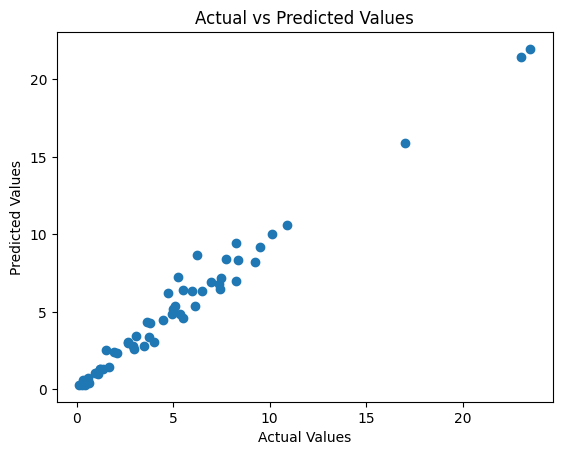

In [27]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

#Stacking the Best 3 Models
Stacking regression is an ensemble learning technique that combines multiple regression models to improve predictive performance. It works by training several base models on the same dataset and then using their predictions as input features for a final model, called a meta-model or blender. The meta-model learns to combine these predictions to produce a more accurate and robust final prediction. By leveraging the strengths of various models, stacking can enhance the overall performance and reduce errors. We will use stacking regression to achieve better results by integrating different models and optimizing their combined predictions.

In [28]:
from sklearn.ensemble import GradientBoostingRegressor, BaggingRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge



# Initialize individual models with the best parameters
gbr = GradientBoostingRegressor(
    learning_rate=0.05173485824291856,
    max_depth=4,
    min_samples_leaf=1,
    min_samples_split=16,
    n_estimators=153,
    subsample=0.9616371726832453,
    random_state=42
)

bagging = BaggingRegressor(random_state=42)

extratrees = ExtraTreesRegressor(random_state=42)

# Define the stacking model
estimators = [
    ('gbr', gbr),
    ('bagging', bagging),
    ('extratrees', extratrees)
]

# Use Ridge as the final estimator (meta-model)
stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5
)

# Train the stacking model
stacking_regressor.fit(X_train, y_train)

# Make predictions on the test data
y_pred = stacking_regressor.predict(X_test)

# Calculate R-squared
r_squared = r2_score(y_test, y_pred)

# Calculate Adjusted R-squared
n = X_test.shape[0]  # Number of samples
p = X_test.shape[1]  # Number of features
adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print the results
print(f"R-squared: {r_squared}")
print(f"Adjusted R-squared: {adjusted_r_squared}")
print(f"RMSE: {rmse}")

# Optionally, print the first few predicted values alongside the actual values
print(pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).head())

R-squared: 0.9788380719410951
Adjusted R-squared: 0.9769142602993764
RMSE: 0.6981958052102613
     Actual  Predicted
177    0.35       0.47
289   10.11      10.41
228    4.95       5.07
198    0.15       0.09
60     6.95       6.79


By employing a stacking regression approach with the best-performing models from the LazyPredict benchmark, we achieved improved results. The new model delivered an R-squared of 0.98 and an RMSE of 0.70, reflecting better accuracy and a closer fit to the data. The stacking method effectively combined the strengths of GradientBoostingRegressor, Bagging, and ExtraTrees with Ridge regression as the meta-model, enhancing overall predictive performance.

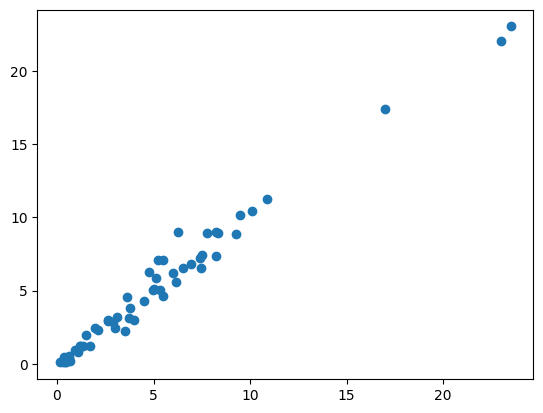

In [29]:
plt.scatter(y_test,y_pred)

In [30]:
# Stacking the Best 4 Models
from sklearn.ensemble import GradientBoostingRegressor, BaggingRegressor, ExtraTreesRegressor, RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge

# Initialize individual models with the best parameters
gbr = GradientBoostingRegressor(
    learning_rate=0.05173485824291856,
    max_depth=4,
    min_samples_leaf=1,
    min_samples_split=16,
    n_estimators=153,
    subsample=0.9616371726832453,
    random_state=42
)

bagging = BaggingRegressor(random_state=42)

extratrees = ExtraTreesRegressor(random_state=42)

randomforest = RandomForestRegressor(random_state=42)

# Define the stacking model
estimators = [
    ('gbr', gbr),
    ('bagging', bagging),
    ('extratrees', extratrees),
    ('randomforest', randomforest)
]

# Use Ridge as the final estimator (meta-model)
stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=10
)

# Train the stacking model
stacking_regressor.fit(X_train, y_train)

# Make predictions on the test data
y_pred = stacking_regressor.predict(X_test)

# Calculate R-squared
r_squared = r2_score(y_test, y_pred)

# Calculate Adjusted R-squared
n = X_test.shape[0]  # Number of samples
p = X_test.shape[1]  # Number of features
adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print the results
print(f"R-squared: {r_squared}")
print(f"Adjusted R-squared: {adjusted_r_squared}")
print(f"RMSE: {rmse}")

# Optionally, print the first few predicted values alongside the actual values
print(pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).head())

R-squared: 0.9823283059849381
Adjusted R-squared: 0.9807217883472052
RMSE: 0.6380264893408922
     Actual  Predicted
177    0.35       0.45
289   10.11      10.25
228    4.95       4.93
198    0.15       0.10
60     6.95       6.77


<Axes: xlabel='Selling_Price', ylabel='Density'>

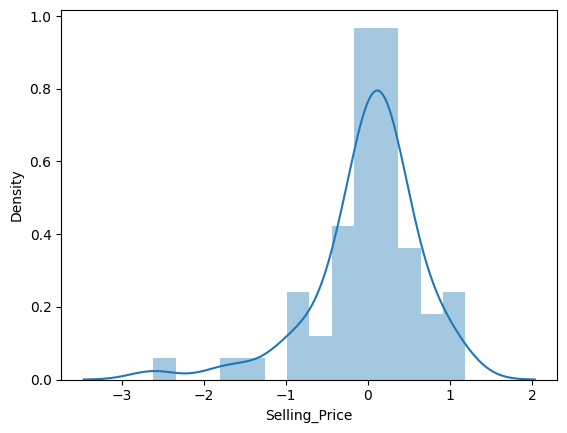

In [31]:
# Calculating the error
Error = y_test - y_pred

sns.distplot(Error)

This plot shows the error or the difference between the predictions and the true values. As long as the distribution is approximately normal with a peak at 0, this indicates that the predictions are good.

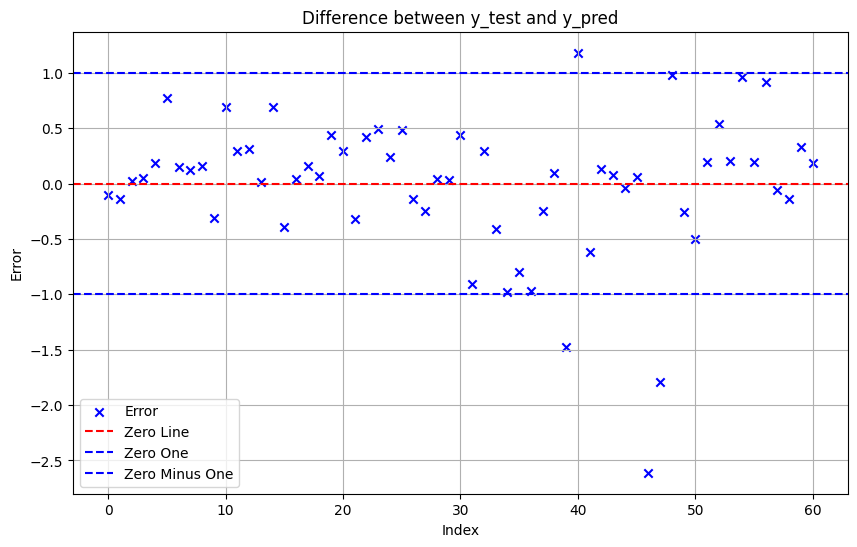

In [32]:
#Error Interval Selection
# Calculating the error
Error = y_test - y_pred

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(range(len(Error)), Error, color='b', label='Error', marker='x')
plt.axhline(0, color='r', linestyle='--', label='Zero Line')
plt.axhline(1, color='b', linestyle='--', label='Zero One')
plt.axhline(-1, color='b', linestyle='--', label='Zero Minus One')
plt.xlabel('Index')
plt.ylabel('Error')
plt.title('Difference between y_test and y_pred')
plt.legend()
plt.grid(True)
plt.show()


Here, we observe that the error interval is within [-1, 1], with minimal outliers beyond this range. It is important to include this interval on the website if these models are used for predictions. Car dealers should be aware of this interval to understand the potential error involved and to gauge how much the predictions might differ from the actual values.

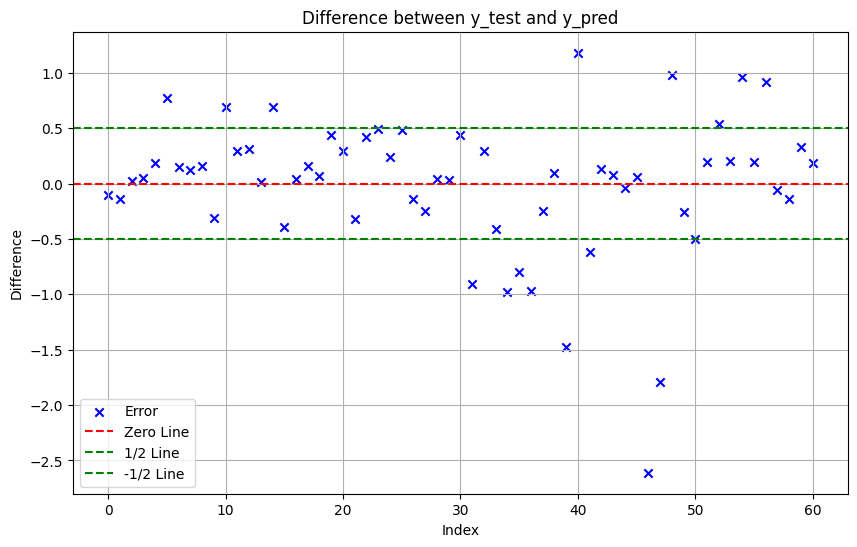

In [33]:
# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(range(len(Error)), Error, color='b', label='Error', marker='x')
plt.axhline(0, color='r', linestyle='--', label='Zero Line')
plt.axhline(0.5, color='g', linestyle='--', label='1/2 Line')
plt.axhline(-0.5, color='g', linestyle='--', label='-1/2 Line')
plt.xlabel('Index')
plt.ylabel('Difference')
plt.title('Difference between y_test and y_pred')
plt.legend()
plt.grid(True)
plt.show()

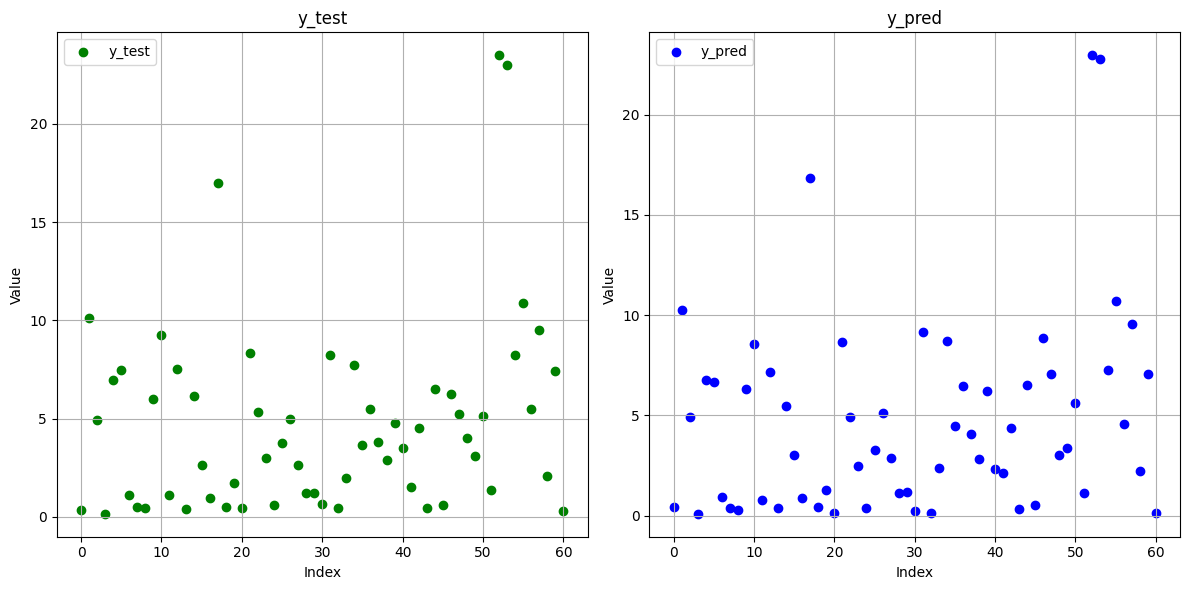

In [34]:
#Predictions
plt.figure(figsize=(12, 6))

# Plot for y_test
plt.subplot(1, 2, 1)
plt.scatter(range(len(y_test)), y_test, color='g', label='y_test', marker='o')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('y_test')
plt.grid(True)
plt.legend()

# Plot for y_pred
plt.subplot(1, 2, 2)
plt.scatter(range(len(y_pred)), y_pred, color='b', label='y_pred', marker='o')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('y_pred')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
